In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Week-2

**Note to Learners**:

- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. Ignore the vector $y$. You will be using this dataset for the rest of the assignment. Do not edit this cell.

In [19]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, factor=0.9, noise=0.2, random_state=0)

In [20]:
X.shape
X

array([[ 0.98337762,  0.03271361],
       [-0.01119427, -0.60327421],
       [-0.75002236, -0.94710257],
       ...,
       [ 0.00712504,  0.4884078 ],
       [ 0.78125085,  0.53305995],
       [-0.72139902,  0.54709001]])

In [21]:
y.shape
y

array([1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,

## Problem 1
Plot the dataset using matplotlib.

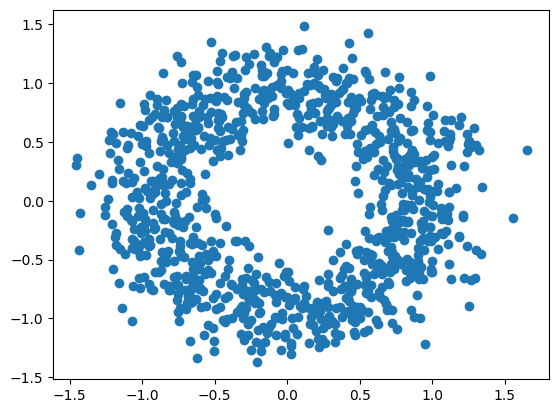

In [22]:
# Enter your solution here
plt.scatter(X[:, 0], X[:, 1])
plt.show()

## Problem 2
How many samples are there in the dataset?


In [23]:
# Enter your solution here
X.shape[0]

1000

## Problem 3
How many features are there in the dataset?

In [24]:
# Enter your solution here
X.shape[1]

2

## Problem 4
Find the kernel matrix $K$ using the polynomial kernel with degree $2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

In [25]:
# Enter your solution here
def polykernel(X,p):
  return (X.dot(X.T)+1)**p

K = polykernel(X,2)
n = K.shape[0]
K_ans = np.sqrt(np.sum(K**2))/n
K_ans

np.float64(2.096195646589988)

## Problem 5
Find the kernel matrix $K$ using the Gaussian kernel with parameter $\sigma = 2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

In [26]:
# Enter your solution here
# since we need to use if for all kernel values we create one fn

def gaussian_kernel(xi, xj, sigma):
    num = -np.linalg.norm(xi - xj)**2  # squared norm
    denom = 2 * sigma**2  # 2sigma*2
    Kij = np.exp(num / denom)  # add exponentiation
    return Kij


def RBFkernel(X, sigma):
    n = X.shape[0]
    K = np.zeros((n, n))  # n*n - zero
    for i in range(n):
        for j in range(n):
            K[i, j] = gaussian_kernel(X[i], X[j], sigma)
    return K


# conversion
n = X.shape[0]
K1 = RBFkernel(X, 2)
K1 = np.sqrt(np.sum(K1**2)) / n
K1

np.float64(0.8079400085320029)

## Problem 6
Find the center of the kernel matrix $K$ obtained in problem 2. Call this centered matrix $KC$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} KC_{ij}^2}
$$

In [27]:
# Enter your solution here
# center the kernel matrix K for p4
def centered_kernel_mat(K):

    # Get shape of actual k as N
    N = K.shape[0]

    # NxN matrix filled with ones, divided by N - normalisation by total
    one_n = np.ones((N, N)) / N

    # Center kernel matrix
    K_centered = K - one_n.dot(K) - K.dot(one_n) + one_n.dot(K).dot(one_n)

    # return output
    return K_centered


# Enter your solution here - calculate KC
KC = centered_kernel_mat(K)

print(round((np.sqrt(np.sum(KC**2))/n), 2))

1.45


## Problem 7
Find the projections (scalar) of all the data points on to the first two principal components obtained using polynomial kernel of degree 2.

<u>Conversion</u>

if $\alpha_1, \alpha_2, ..., \alpha_n$ are the prjections on the first PC and $\beta_1, \beta_2, ..., \beta_n$ are the projections on the second PC, enter the following quantity as your answer correct to two decimal places:

$$\sum_{i = 1}^{n} \alpha_i + \sum_{i = 1}^{n} \beta_i$$

In [28]:
# Enter your solution here
# p = 2
def polykernel(X, p):
    return (X.dot(X.T) + 1)**p


def K_centered(K):
    N = K.shape[0]
    one_n = np.ones((N, N)) / N
    K = K - one_n.dot(K) - K.dot(one_n) + one_n.dot(K).dot(one_n)
    return K

def Projection(M):
    # Compute the eigenvalues and eigenvectors
    eigval, eigvec = np.linalg.eigh(M)  # returns pair in ascending order

    # Extract the two largest eigenvalues
    lambda_1 = eigval[-1]
    lambda_2 = eigval[-2]

    # Extract the corresponding eigenvectors
    v1 = eigvec[:, -1]
    v2 = eigvec[:, -2]

    # Normalize the eigenvectors
    v1_norm = np.linalg.norm(v1)
    v2_norm = np.linalg.norm(v2)

    alpha_1 = v1 / (v1_norm * np.sqrt(lambda_1))
    alpha_2 = v2 / (v2_norm * np.sqrt(lambda_2))

    # Compute the projections
    proj_1 = np.dot(alpha_1, M)
    proj_2 = np.dot(alpha_2, M)

    return proj_1, proj_2

pc1, pc2 = Projection(KC)  # centered kernel matrix
print((np.abs(pc1).sum() + np.abs(pc2).sum()) / len(pc2))

1.7447267990953328
